In [ ]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [62]:
# Truco para que Jupyter lea siempre la última versión de la carpeta src/
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
from src.data_loader import loader
from src.model_trainer import optimizar_hiperparametros_modelo
from src.evaluator import evaluar_modelo, calcular_metricas

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.linear_model import LinearRegression, LogisticRegression
from xgboost import XGBClassifier

import joblib
import src.config as config

In [21]:
X_train, X_test, y_train, y_test = loader(OHE=True)

print("¡Datos cargados con éxito! Tamaño de entrenamiento:", X_train.shape)

c:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [7, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


¡Datos cargados con éxito! Tamaño de entrenamiento: (95189, 408)


In [17]:
#### Logistic Regression

In [22]:
modelo_rl = LogisticRegression(max_iter=500, random_state=42) 
modelo_rl.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [23]:
param_grid_rl = {
    # Probar regularización L1 (Lasso) y L2 (Ridge)
    'penalty': ['l2'],
    # Fuerza de la regularización
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    # Algoritmo de optimización que soporta penalizaciones l1 y l2
    'solver': ['liblinear'] 
}

In [24]:
mejor_rl, hiperparametros_rl = optimizar_hiperparametros_modelo(
    modelo_rl, 
    param_grid_rl, 
    X_train, 
    y_train
)

print('\n¡Optimización terminada!')
print('Los mejores parámetros encontrados son:\n', hiperparametros_rl)

c:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



¡Optimización terminada!
Los mejores parámetros encontrados son:
 {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
# Predicciones con el mejor modelo y probabilidades
y_pred_train = mejor_rl.predict(X_train)
y_pred_test = mejor_rl.predict(X_test)

In [ ]:
# Solo la columna 1. La clase 1
y_proba_test = mejor_rl.predict_proba(X_test)[:, 1]


	  Reporte de clasificación (Entrenamiento) - Regresión Logística Optimizada
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.82      0.85     59897
           1       0.73      0.82      0.77     35292

    accuracy                           0.82     95189
   macro avg       0.81      0.82      0.81     95189
weighted avg       0.83      0.82      0.82     95189


	  Reporte de clasificación (Test) - Regresión Logística Optimizada
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.82      0.85     14975
           1       0.73      0.82      0.77      8823

    accuracy                           0.82     23798
   macro avg       0.81      0.82      0.81     23798
weighted avg       0.83      0.82      0.82     23798



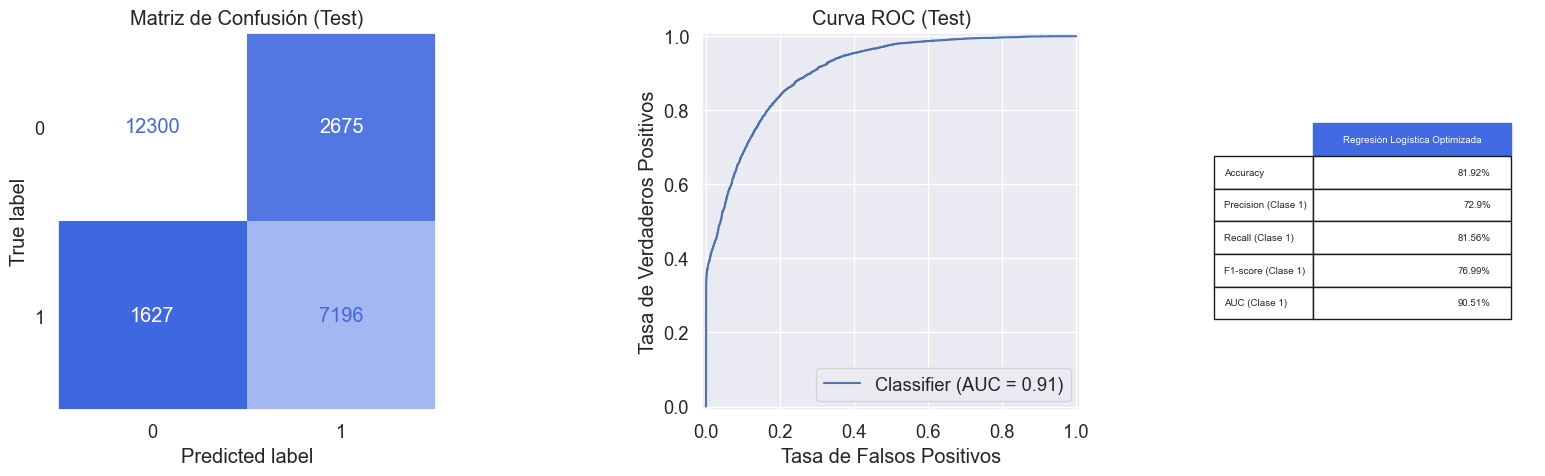

In [28]:
evaluar_modelo(
    y_train, 
    y_test, 
    y_pred_train, 
    y_pred_test, 
    y_proba_test, 
    'Regresión Logística Optimizada'
)

In [33]:
lr_results = calcular_metricas(y_test, y_pred_test, y_proba_test, 'Logistic Regression')
lr_results

,Logistic Regression
Accuracy,81.92%
Precision (Clase 1),72.9%
Recall (Clase 1),81.56%
F1-score (Clase 1),76.99%
AUC (Clase 1),90.51%


In [47]:
# Guardar el modelo en un .pkl
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# 2. Guardamos nuestro árbol ganador usando la ruta de tu config.py
joblib.dump(mejor_rl, config.RL_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {config.RL_MODEL_PATH}!")

¡Modelo guardado con éxito en: C:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\models\tests\logistic_regression.pkl!


In [39]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
cm

array([[12300,  2675],
       [ 1627,  7196]])

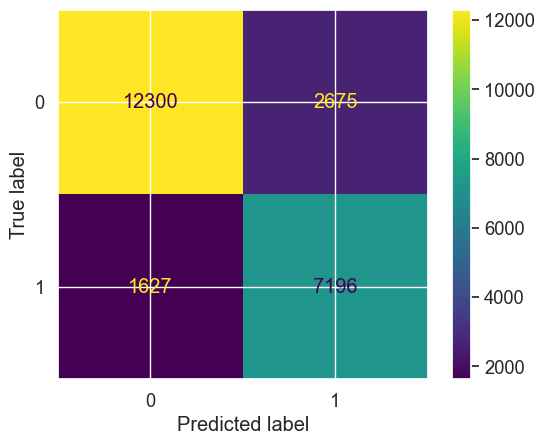

In [40]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

#### Decisision Tree Classifier

In [ ]:
dt_base = DecisionTreeClassifier(random_state=0)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

mejor_arbol, hiperparametros = optimizar_hiperparametros_modelo(dt_base, param_grid_dt, X_train, y_train)

print('¡Entrenamiento terminado! Los mejores parámetros son:\n', hiperparametros)

¡Entrenamiento terminado! Los mejores parámetros son:
 {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# Predicciones
y_pred_train = mejor_arbol.predict(X_train)
y_pred_test = mejor_arbol.predict(X_test)

In [ ]:
# Las probabilidades de clase 1
y_proba_test = mejor_arbol.predict_proba(X_test)[:, 1]


	  Reporte de clasificación (Entrenamiento) - Árbol de Decisión
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59897
           1       0.99      1.00      0.99     35292

    accuracy                           1.00     95189
   macro avg       1.00      1.00      1.00     95189
weighted avg       1.00      1.00      1.00     95189


	  Reporte de clasificación (Test) - Árbol de Decisión
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     14975
           1       0.79      0.80      0.80      8823

    accuracy                           0.85     23798
   macro avg       0.84      0.84      0.84     23798
weighted avg       0.85      0.85      0.85     23798



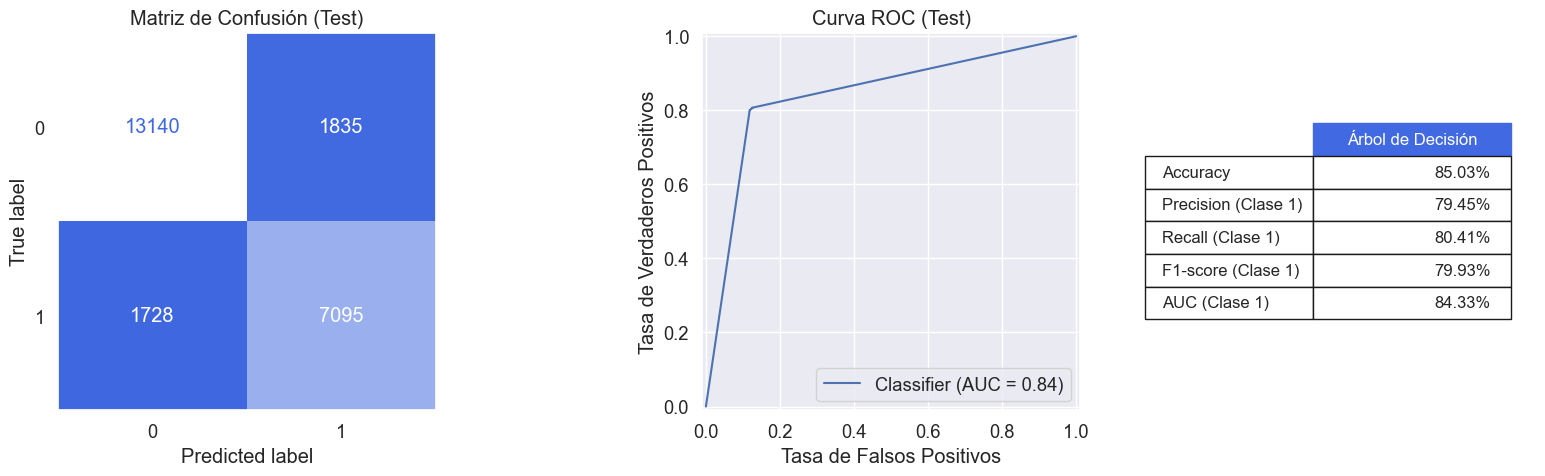

In [45]:
# Métricas de evaluación
evaluar_modelo(y_train, y_test, y_pred_train, y_pred_test, y_proba_test, 'Árbol de Decisión')

In [46]:
dt_results = calcular_metricas(y_test, y_pred_test, y_proba_test, 'Decision Tree')
dt_results

,Decision Tree
Accuracy,85.03%
Precision (Clase 1),79.45%
Recall (Clase 1),80.41%
F1-score (Clase 1),79.93%
AUC (Clase 1),84.33%


In [ ]:
# .pkl
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# guardar el árbol
joblib.dump(mejor_arbol, config.DT_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {config.DT_MODEL_PATH}!")

¡Modelo guardado con éxito en: C:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\models\tests\tree.pkl!


In [49]:
#### XGBoost

In [ ]:
# Calcular el peso matemático del desbalanceo para las cancelaciones
total_negativos = (y_train == 0).sum()
total_positivos = (y_train == 1).sum()
peso_cancelaciones = total_negativos / total_positivos

print(f"Peso calculado para XGBoost (scale_pos_weight): {peso_cancelaciones:.2f}")

Peso calculado para XGBoost (scale_pos_weight): 1.70


In [ ]:
xgb_base = XGBClassifier(
    random_state=42, 
    scale_pos_weight=peso_cancelaciones,
    eval_metric='logloss'
)

In [ ]:
# Grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

In [54]:
# mejores hiperparámetros
mejor_xgb, hiperparametros_xgb = optimizar_hiperparametros_modelo(
    xgb_base, 
    param_grid_xgb, 
    X_train, 
    y_train
)

print("\nEntrenando XGBoost... (Esto puede tardar unos minutos)")
print('\n¡Entrenamiento terminado!')
print('Mejores hiperparámetros:', hiperparametros_xgb)


Entrenando XGBoost... (Esto puede tardar unos minutos)

¡Entrenamiento terminado!
Mejores hiperparámetros: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}


In [55]:
# Las predicciones
y_pred_train = mejor_xgb.predict(X_train)
y_pred_test = mejor_xgb.predict(X_test)

In [56]:
# Probabilidades de cancelación
y_proba_test = mejor_xgb.predict_proba(X_test)[:, 1]


	  Reporte de clasificación (Entrenamiento) - XGBoost Optimizado
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     59897
           1       0.84      0.91      0.87     35292

    accuracy                           0.90     95189
   macro avg       0.89      0.91      0.90     95189
weighted avg       0.91      0.90      0.90     95189


	  Reporte de clasificación (Test) - XGBoost Optimizado
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.87      0.90     14975
           1       0.80      0.87      0.83      8823

    accuracy                           0.87     23798
   macro avg       0.86      0.87      0.87     23798
weighted avg       0.88      0.87      0.87     23798



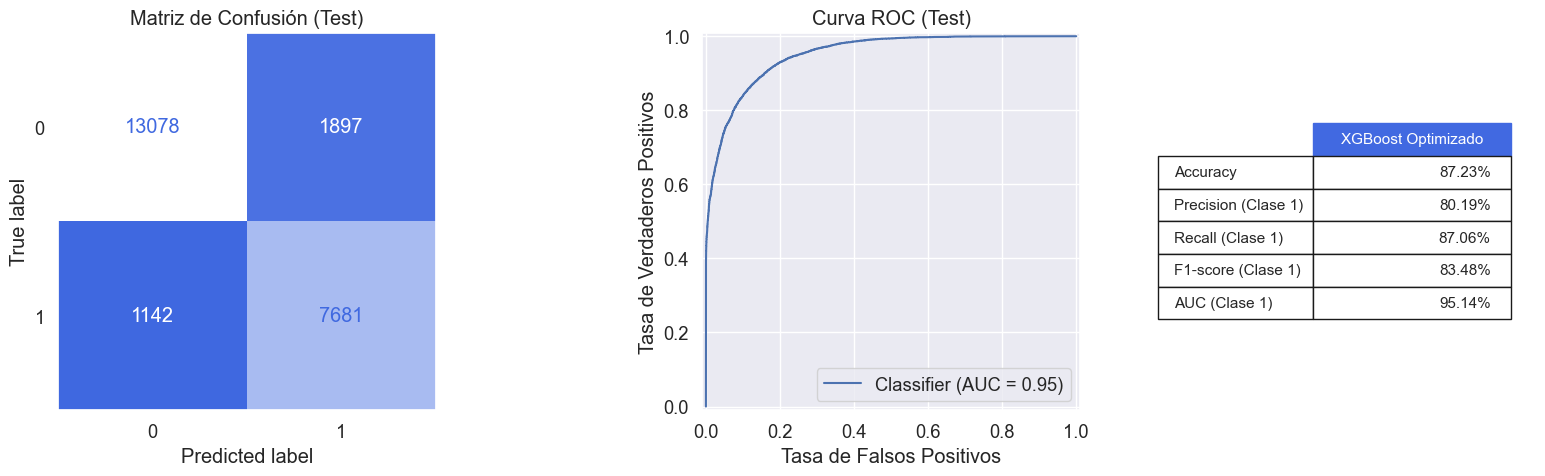

In [59]:
# Evaluar los resultados
evaluar_modelo(y_train, y_test, y_pred_train, y_pred_test, y_proba_test, 'XGBoost Optimizado')

In [60]:
xgb_results = calcular_metricas(y_test, y_pred_test, y_proba_test, 'XGBoost')
xgb_results

,XGBoost
Accuracy,87.23%
Precision (Clase 1),80.19%
Recall (Clase 1),87.06%
F1-score (Clase 1),83.48%
AUC (Clase 1),95.14%


In [67]:
# .pkl
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# guardar el árbol
joblib.dump(mejor_xgb, config.XGB_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {config.XGB_MODEL_PATH}!")

AttributeError: module 'src.config' has no attribute 'XGB_MODEL_PATH'

#### RandomForestCalssifier
- se hace una búsqueda de hiperparámetros óptimos vía GridSearchCV
- se saca la importancia de las features en la clasificación
- se scan las métricas de clasificación
- se serializa el modelo en un pkl

In [50]:
modelo_rfc = RandomForestClassifier()

dict_parametros = {
    'n_estimators': [50, 100, 300],
    'max_depth': [8,10,12], #[6,8,10],
    'class_weight': ['balanced'],
    'n_jobs': [-1]
}
# Entrenamiento de un modelo de RandomForest Classifier
mejor_rfc, hiperparametros = optimizar_hiperparametros_modelo(modelo_rfc, dict_parametros, X_train, y_train)

print('¡Entrenamiento terminado! Los mejores parámetros son:\n', hiperparametros)

KeyboardInterrupt: 

In [ ]:
# Métricas de evaluación
#evaluar_modelo(mejor_rfc, X_train, X_test, y_train, y_test, 'RandomForestClassifier')
y_pred_train = mejor_rfc.predict(X_train)
y_pred_test = mejor_rfc.predict(X_test)
y_proba_test = mejor_rfc.predict_proba(X_test)
evaluar_modelo(y_train, y_test, y_pred_train, y_pred_test, y_proba_test, 'RandomForestClassifier')

In [ ]:
# Guardar el modelo en un .pkl
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# 2. Guardamos rfc ganador usando la ruta de tu config.py
joblib.dump(mejor_arbol, config.RFC_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {config.RFC_MODEL_PATH}!")

In [ ]:
# Feature importance
importances = mejor_rfc.feature_importances_
feature_imp = pd.DataFrame({'Feature': X_train.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
feature_imp.head(15)

,Feature,Gini Importance
47,deposit_type_Non Refund,0.138682
14,country_PRT,0.119329
415,lead_time,0.099751
426,total_of_special_requests,0.067021
425,required_car_parking_spaces,0.047185
420,previous_cancellations,0.045252
422,booking_changes,0.032204
413,customer_type_Transient,0.031962
18,market_segment_Groups,0.030139
20,market_segment_Online TA,0.024243


In [ ]:
import re
feature_importance = {c:0 for c in dset.columns}
for index,row in feature_imp.iterrows():
    for feature in feature_importance.keys():
        sr = re.search(feature, row['Feature'])
        if sr:
            feature_importance[sr.group()] += row['Gini Importance']

In [ ]:
pd.Series(dict(sorted(feature_importance.items(), key = lambda item: item[1], reverse=True)))

country                           0.175340
deposit_type                      0.138814
lead_time                         0.099751
market_segment                    0.087951
agent                             0.080158
total_of_special_requests         0.067021
customer_type                     0.056621
required_car_parking_spaces       0.047185
previous_cancellations            0.045252
distribution_channel              0.035783
booking_changes                   0.032204
adr                               0.023903
assigned_room_type                0.019520
company                           0.015531
hotel                             0.011393
stays_in_week_nights              0.011224
previous_bookings_not_canceled    0.010543
arrival_date_week_number          0.008435
reserved_room_type                0.007703
meal                              0.005469
stays_in_weekend_nights           0.005467
days_in_waiting_list              0.005253
is_repeated_guest                 0.004877
arrival_dat

#### Neural Network

In [ ]:
# Definimos la arquitectura del modelo
model_nn = models.Sequential(layers=[
    layers.Input(shape=(X_train.shape[1],), name='i1'),
    layers.Dense(128, activation='relu', name='h1'),
    layers.Dense(64, activation='relu', name='h2'),
    layers.Dense(32, activation='relu', name='h3'),
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilamos el modelo
optimizer_adam = Adam(learning_rate=0.001)
model_nn.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['recall'])

Se observa que el modelo converge rápidamente; ha estado bien cortar temprano porqué ya no había gananccia el loss y val_loss tenía tendencia creciente (la ganancia en loss iba a ser por overfitting)

In [ ]:
%%time
# Se entrena el modelo con un callback de early stopping. Se aplic en el val_loss porqué no se quiere overfitting
callback = EarlyStopping(monitor="val_loss",
                         min_delta=0.02,
                         patience=3,  # número de veces con una ganancia por debajo de la mínima seguidas antes de parar
                         verbose=0,
                         mode="auto",
                         baseline=None,
                         restore_best_weights=False,
                         start_from_epoch=0,
                        )
history = model_nn.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=1, callbacks=[callback])

Epoch 1/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.3515 - recall: 0.7162 - val_loss: 0.3234 - val_recall: 0.7710
Epoch 2/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.3170 - recall: 0.7569 - val_loss: 0.3177 - val_recall: 0.8136
Epoch 3/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.3064 - recall: 0.7609 - val_loss: 0.3108 - val_recall: 0.7875
Epoch 4/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.3004 - recall: 0.7707 - val_loss: 0.3009 - val_recall: 0.7632
Epoch 5/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2937 - recall: 0.7734 - val_loss: 0.3018 - val_recall: 0.7977
Epoch 6/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.2895 - recall: 0.7798 - val_loss: 0.3025 - val_recall: 0.7840
Epoch 7/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2851 - recall: 0.7846 - val_loss: 0.3015 - val_recall: 0.7853
CPU times: user 1min 35s, sys: 31.2 s, total: 2min 6s
Wall time: 1min 11s


In [ ]:
print('¡Entrenamiento terminado!)

In [ ]:
def nn_predict(model, X, threshold=0.5: float, pred_or_proba='pred') -> (pd.core.series.Series, pd.core.series.Series):
    '''
    Retorna (y_pred, y_pred_proba) o un diccionario con código de error 'code' y mensaje 'msg' 
    threshold debe estar entre 0 y 1, es el umbral de probabilidad a partir del cual se toma el resultado como '1'
    pred_or_proba dbe valer o 'pred' o 'proba'
    '''    
    if not (threshold >= 0 and threshold <= 0.5):
        return {'code':1,
                'msg': 'threshold debe estar entre 0 y 1, incluidos'}
    y_proba = model_nn.predict(X_test) 
    y_pred_proba = pd.Series(y_proba.flatten())
    if pred_or_proba == 'proba':     
        return y_pred_proba    
    elif pred_or_proba =0 'pred':
        return y_pred_proba.map(lambda x: 1 if x > threshold else 0)
    else:
        return {'code':2,
                'msg': 'pred_or_proba debe valer pred o proba'}

In [ ]:
# Métricas de evaluación
y_pred_train = mejor_rfc.nn_predict(model_nn, X_train)
y_pred_test = mejor_rfc.nn_predict(model_nn, X_test)
y_proba_test = mejor_rfc.nn_predict(model_nn, X_train, pred_or_proba='proba')
evaluar_modelo(y_train, y_test, y_pred_train, y_pred_test, y_proba_test, 'NeuralNetwork')

In [ ]:
# Guardar el modelo en un .pkl
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# 2. Guardamos rfc ganador usando la ruta de tu config.py
joblib.dump(model_nn, config.NN_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {config.NN_MODEL_PATH}!")